

```
# Questo è formattato come codice
```

progetto ABIML 2025-26__Seconda versione

Bresciani G.

Loreggia C.

Magni G.

Rota Biasetti S.

# Section 1



Mount Google Drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell to download the dataset from Hugging Face and save it directly to your Google Drive. (Run only once)

Data Loading
Note: Just like in our lab sessions, we don't use our own images. Instead, we use a dataset from Hugging Face. There are two ways to do this:

Method 1 — Local Caching: Downloading the data directly from Hugging Face to the Colab temporary memory.

Method 2 — Google Drive: Saving the data on Google Drive and connecting it to Colab.

Our Choice: The Alzheimer MRI dataset is only 30MB. Because it is so small, we decided to use Method 2 (Google Drive).

Usually, moving data between Drive and Colab can be slow, but for 30MB the delay is not a problem. Also, both services use Google’s infrastructure, so the speed is very fast. Using "streaming" or "lazy loading" from Hugging Face is only necessary for very large datasets (100GB or more). For this project, saving it to Drive is the easiest and best solution.

In [8]:
#from datasets import load_dataset

#Downloading all dataset from HF
#dataset = load_dataset("Falah/Alzheimer_MRI")

# Save on Drive (.arrow)
#dataset.save_to_disk("/content/drive/MyDrive/Project_For_ABIAML/dataset")

In [9]:
import os
DATA_FOLDER = os.path.join("/content/drive/MyDrive/Project_For_ABIAML/dataset")
print("Available folders:", os.listdir(DATA_FOLDER))

Available folders: ['train', 'test', 'dataset_dict.json']


Shape uniche train: {(128, 128)}
Shape uniche test:  {(128, 128)}
--- Dimensioni del Dataset ---
Split 'train': 5120 immagini
Split 'test': 1280 immagini

--- Associazione Etichette-Numeri ---
Label 0 -> Mild_Demented
Label 1 -> Moderate_Demented
Label 2 -> Non_Demented
Label 3 -> Very_Mild_Demented

--- Dettagli Immagine e Normalizzazione (Singolo Campione) ---
Shape immagine: (128, 128)
Valori originali dei pixel - Min: 0, Max: 157
Valori normalizzati (0-1) - Min: 0.0, Max: 0.615686274509804


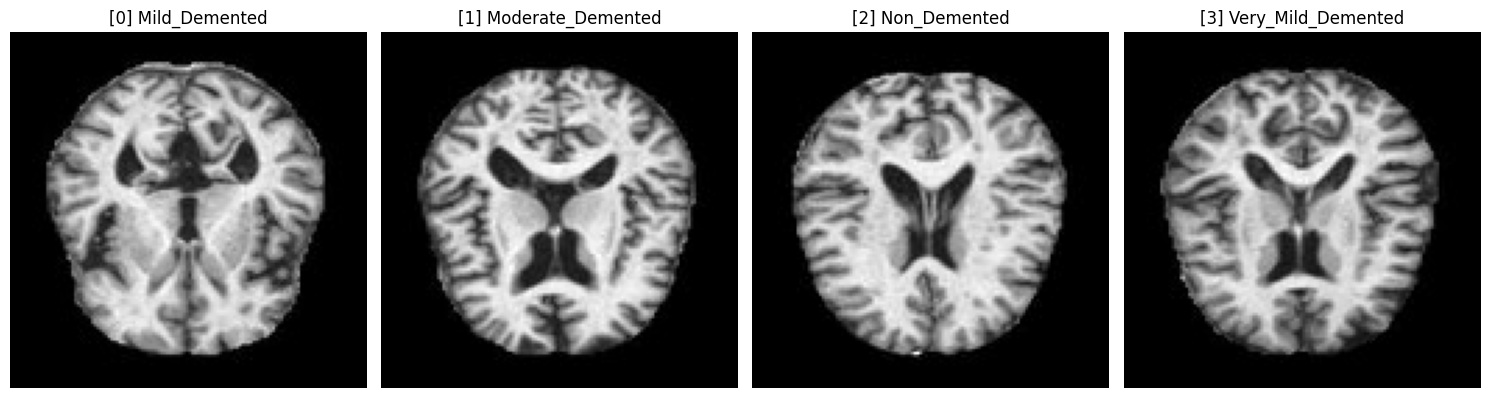

In [10]:
from datasets import load_from_disk

dataset = load_from_disk(DATA_FOLDER)
import numpy as np
import matplotlib.pyplot as plt


# analisi del numero di canali di colore ( nessuno = 1 implicito, 3 = RBG, 4= RGBA)
shapes_train = set(np.array(img['image']).shape for img in dataset['train'])
shapes_test  = set(np.array(img['image']).shape for img in dataset['test'])
print(f"Shape uniche train: {shapes_train}")
print(f"Shape uniche test:  {shapes_test}")




# --- 1. ESPLORAZIONE DEL DATASET ---
print("--- Dimensioni del Dataset ---")
for split in dataset.keys():
    print(f"Split '{split}': {len(dataset[split])} immagini")

# --- 2. ESTRAZIONE DINAMICA DELLE ETICHETTE ---
# Estraiamo i nomi direttamente dalle "features" del dataset di train
label_names = dataset['train'].features['label'].names
print(f"\n--- Associazione Etichette-Numeri ---")
for num, name in enumerate(label_names):
    print(f"Label {num} -> {name}")

# --- 3. CONVERSIONE E NORMALIZZAZIONE ---
print("\n--- Dettagli Immagine e Normalizzazione (Singolo Campione) ---")
# Prendiamo la prima immagine per controllare i valori
sample = dataset['train'][0]
img_array_originale = np.array(sample['image'])

print(f"Shape immagine: {img_array_originale.shape}")
print(f"Valori originali dei pixel - Min: {img_array_originale.min()}, Max: {img_array_originale.max()}")

# Eseguiamo la normalizzazione da 0 a 1
img_array_normalizzata = img_array_originale / 255.0
print(f"Valori normalizzati (0-1) - Min: {img_array_normalizzata.min()}, Max: {img_array_normalizzata.max()}")

# --- 4. VISUALIZZAZIONE DI UN ESEMPIO PER CLASSE ---
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
shown = {}

# Cerchiamo dinamicamente un'immagine per ciascuna delle 4 categorie
for sample in dataset['train']:
    l = sample['label']
    # Se non abbiamo ancora un'immagine per questa label, la salviamo
    if l not in shown:
        # La convertiamo e la normalizziamo prima di salvarla
        img_norm = np.array(sample['image']) / 255.0
        shown[l] = img_norm
    # Se le abbiamo trovate tutte e 4, fermiamo il ciclo
    if len(shown) == 4:
        break

# Disegniamo le 4 immagini trovate, in ordine di etichetta
for i, (l, img) in enumerate(sorted(shown.items())):
    axes[i].imshow(img, cmap='gray') # cmap='gray' gestisce perfettamente i valori normalizzati 0-1
    axes[i].set_title(f"[{l}] {label_names[l]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [11]:
category_counts = {name: {'train': 0, 'test': 0} for name in label_names}

for split_name in ['train', 'test']:
    for sample in dataset[split_name]:
        label_index = sample['label']
        category_name = label_names[label_index]
        category_counts[category_name][split_name] += 1

print("--- Conteggio immagini per categoria ---")
for category, counts in category_counts.items():
    print(f"Categoria '{category}':")
    print(f"  Training set: {counts['train']} immagini")
    print(f"  Test set: {counts['test']} immagini")
    print(f"  Totale: {counts['train'] + counts['test']} immagini\n")

--- Conteggio immagini per categoria ---
Categoria 'Mild_Demented':
  Training set: 724 immagini
  Test set: 172 immagini
  Totale: 896 immagini

Categoria 'Moderate_Demented':
  Training set: 49 immagini
  Test set: 15 immagini
  Totale: 64 immagini

Categoria 'Non_Demented':
  Training set: 2566 immagini
  Test set: 634 immagini
  Totale: 3200 immagini

Categoria 'Very_Mild_Demented':
  Training set: 1781 immagini
  Test set: 459 immagini
  Totale: 2240 immagini



**Class Distribution**

Before building any model, it is essential to understand how the dataset is distributed across the different classes.

A "balanced" dataset is important. If the dataset is unbalanced (meaning one class has many more images than the others), the network might "cheat." It could learn to always predict the most frequent class to get a high accuracy score, but it would completely fail to recognize the rare classes.

This is a critical issue in the medical field, where the rarest classes are often the most important to identify correctly.

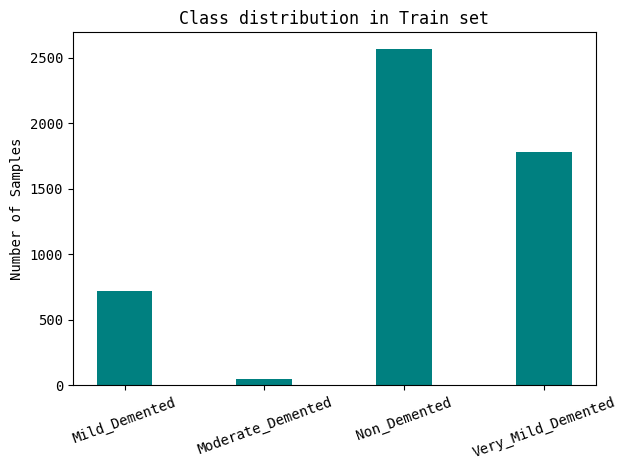

In [12]:
import numpy as np

label_names = dataset['train'].features['label'].names
# label_names è una lista ["Mild_Demented", "Moderate_Demented",
# "Non_Demented", "Very_Mild_Demented"] — ci serve per stampare i nomi
# invece dei numeri 0,1,2,3

train_labels = np.array(dataset['train']['label'])

unique, counts = np.unique(train_labels, return_counts=True)
# np.unique trova i valori unici in train_labels (0,1,2,3) e conta
# quante volte appare ciascuno → unique=[0,1,2,3], counts=[n0,n1,n2,n3]

plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 10
plt.bar([label_names[i] for i in unique], counts, color=(0, 0.5, 0.5),width=0.4)
plt.title('Class distribution in Train set', loc='center')
plt.ylabel('Number of Samples')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



Looking at our data: 'Non_Demented' has 2566 training images while 'Moderate_Demented' has only 49. a ratio of about 52:1. One practical solution is to use class weights during training so the model receives a higher penalty when it makes an error on a rare class, forcing it to pay more attention to them.

# Eliminare questa nota prima della consegna

Ricordiamoci di fare una versione applicando il peso dell'errore 'maggiore' per la classe con pochi elementi

# Section 2

In the next cell, we demonstrate how to reduce the number of samples to shorten training time. This approach is often necessary to prevent RAM limitations and crashes. However, in the subsequent steps, we will use the full dataset to maximize the model's accuracy and performance.

In [13]:
import random
from datasets import Dataset

MAX = 500

def subsample(split):
    indices = {name: [] for name in label_names}
    for i, s in enumerate(dataset[split]):
        indices[label_names[s['label']]].append(i)
    kept = []
    for name, idx in indices.items():
        kept += random.sample(idx, min(MAX, len(idx)))
    return dataset[split].select(kept)

train_balanced = subsample('train')
print({label_names[i]: sum(1 for s in train_balanced if s['label']==i) for i in range(len(label_names))})

{'Mild_Demented': 500, 'Moderate_Demented': 49, 'Non_Demented': 500, 'Very_Mild_Demented': 500}


In [14]:
# Questa cella estrae, normalizza, shuffla e prepara train e test
# tutto in una volta sola — nessuna operazione viene ripetuta altrove
import numpy as np
from keras.utils import to_categorical

print("--- 1. Estrazione e Conversione in NumPy ---")
# Estraiamo le immagini, le convertiamo in array NumPy
# Ci vorrà qualche secondo per caricare tutto in memoria
train_images = np.array([np.array(img) for img in dataset['train']['image']])
train_labels = np.array(dataset['train']['label'])

print(f"Dimensioni train_images: {train_images.shape}")

print("\n--- 2. Shuffle (Mescolamento) dei dati ---")
'''
 Shuffle training data (esattamente con la logica usata a lezione)
 Shuffle using np.random.permutation: applies the same random index order
 to both images and labels.
 Not stratified (dataset is just splitted)
 Seed fixed for reproducibility.
'''
# primo tentativo a 42 poi cambiato per verificare
seed=42
np.random.seed(seed)
train_idx = np.random.permutation(len(train_images))
train_images = train_images[train_idx]
train_labels = train_labels[train_idx]

print("Dati mescolati con successo!")

print("\n--- 3. Normalizzazione (0-1) e aggiunta canale ---")
# Normalizziamo qui una volta sola per train e test
# expand_dims aggiunge il canale: (N,128,128) -> (N,128,128,1)
train_images = np.repeat(np.expand_dims(train_images / 255.0, axis=-1), 3, axis=-1)
test_images = np.repeat(np.expand_dims(np.array([np.array(img) for img in dataset['test']['image']]) / 255.0, axis=-1), 3, axis=-1)

print(f"Train shape: {train_images.shape}, max pixel: {train_images.max()}")
print(f"Test shape:  {test_images.shape},  max pixel: {test_images.max()}")
test_labels     = np.array(dataset['test']['label'])

print(f"Train shape: {train_images.shape}, max pixel: {train_images.max()}")
print(f"Test shape:  {test_images.shape},  max pixel: {test_images.max()}")

print("\n--- 4. One-Hot Encoding delle etichette ---")
# One-hot encode labels: num_classes=4 (perché abbiamo 4 categorie!)
# Es: 0 -> [1, 0, 0, 0] | 1 -> [0, 1, 0, 0] | ecc...
train_labels_cat = to_categorical(train_labels, num_classes=4)
test_labels_cat  = to_categorical(test_labels,  num_classes=4)

print(f"Esempio codifica etichetta: {int(train_labels[0])} -> {train_labels_cat[0]}")

--- 1. Estrazione e Conversione in NumPy ---
Dimensioni train_images: (5120, 128, 128)

--- 2. Shuffle (Mescolamento) dei dati ---
Dati mescolati con successo!

--- 3. Normalizzazione (0-1) e aggiunta canale ---
Train shape: (5120, 128, 128, 3), max pixel: 1.0
Test shape:  (1280, 128, 128, 3),  max pixel: 1.0
Train shape: (5120, 128, 128, 3), max pixel: 1.0
Test shape:  (1280, 128, 128, 3),  max pixel: 1.0

--- 4. One-Hot Encoding delle etichette ---
Esempio codifica etichetta: 0 -> [1. 0. 0. 0.]


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

IMAGE_SIZE=train_images.shape[1]
IMAGE_CHANNELS = 3
input_shape = (IMAGE_SIZE, IMAGE_SIZE, IMAGE_CHANNELS)
# Load pre-trained VGG16 without the top classification layers
base_model = tf.keras.applications.VGG16(
  include_top=False,  # Exclude the final Dense layers
  input_shape=input_shape,
  weights='imagenet'  # Use pre-trained ImageNet weights
)

base_model.trainable = True # model used for different purpose
print(f"VGG16 layers: {len(base_model.layers)} (all frozen)")
print(f"VGG16 trainable parameters: {base_model.count_params():,}")

# Build the complete model
model = Sequential([
  base_model,
  GlobalAveragePooling2D(),
  Dense(512, activation='relu'),
  Dropout(0.25),
  Dense(4, activation='softmax') # 4 different labels
], name='VGG16_Transfer')
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 layers: 19 (all frozen)
VGG16 trainable parameters: 14,714,688


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,979,396 (57.14 MB)

 Trainable params: 14,979,396 (57.14 MB)

 Non-trainable params: 0 (0.00 B)

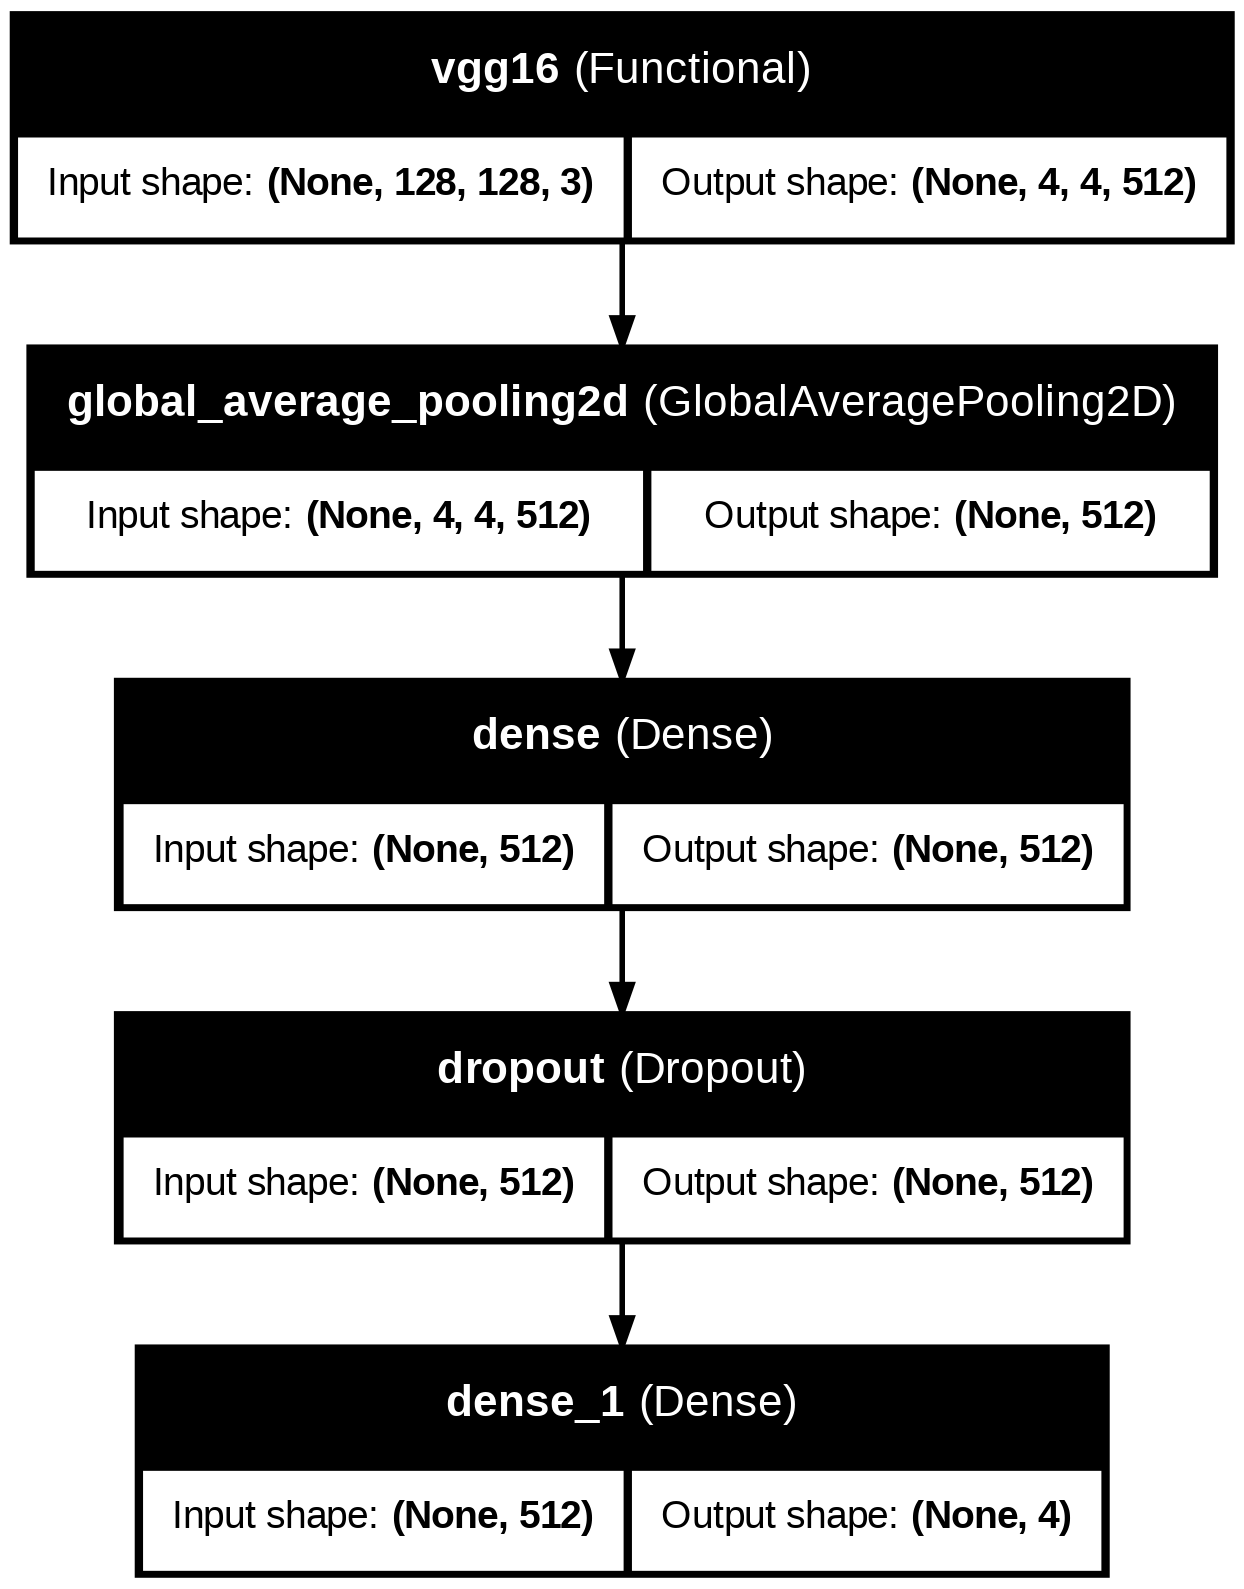

In [16]:
# Visualizzazione grafica dell'architettura
tf.keras.utils.plot_model(
    model,
    to_file='model_architecture_vgg16.png', # Salva anche l'immagine nel tuo Drive/Colab
    show_shapes=True,                  # Mostra le dimensioni degli input/output (fondamentale!)
    show_layer_names=True              # Mostra il nome di ogni livello (es. conv2d_1)
)

MODEL COMPILE

In [17]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping #  <-- AGGIUNTO EARLYSTOPPING

print("--- 1. Compilazione del Modello ---")

# Compiliamo il modello
model.compile(
    # Il learning rate controlla la "velocità" con cui il modello impara.
    # N.B. Questo è uno dei parametri principali da modificare per il vostro Sub-Task 1!
    optimizer=Adam(learning_rate=1e-5), # <-- abbassato per migliorare apprendimento

    # MODIFICA FONDAMENTALE: Usiamo 'categorical' (per 4 classi) e non 'binary' (per 2 classi)
    loss='categorical_crossentropy',

    metrics=['accuracy']
)

print("--- 2. Impostazione del Checkpoint ---")

# Il Checkpoint è un salvataggio automatico.
# Se all'epoca 8 il modello è perfetto ma all'epoca 10 peggiora (overfitting),
# questa funzione ti salva in automatico la versione dell'epoca 8.
checkpoint = ModelCheckpoint(
    # Ho messo un nome file locale per Colab.
    # (Se vuoi usare 'drive/MyDrive/...' ricordati che devi prima montare Google Drive!)
    filepath='best_vgg16_alzheimer.keras',
    monitor='val_loss',                    # Guarda l'errore sul set di validazione
    mode='min',                            # Cerca di minimizzare questo errore
    save_best_only=True,                   # Salva SOLO se batte il record precedente
    verbose=1
)

print("--- 3. Impostazione EarlyStopping ---") # <-- AGGIUNTO PER EVITARE CHE CONTINUI SE NON STA MIGLIORANDO DA MOLTO
# Si ferma automaticamente se val_loss non migliora per 10 epoche consecutive
# restore_best_weights=True: ripristina i pesi dell'epoca migliore alla fine
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("Modello compilato e Checkpoint e EarlyStopping pronto!")

--- 1. Compilazione del Modello ---
--- 2. Impostazione del Checkpoint ---
--- 3. Impostazione EarlyStopping ---
Modello compilato e Checkpoint e EarlyStopping pronto!


In [18]:
# Esempio di come lanciare l'addestramento includendo il checkpoint
history = model.fit(
    train_images,
    train_labels_cat,
    epochs=3,
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop]    # <--- ECCO LA MAGIA QUI!
)

Epoch 1/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4697 - loss: 1.1003
Epoch 1: val_loss improved from None to 0.86999, saving model to best_vgg16_alzheimer.keras

Epoch 1: finished saving model to best_vgg16_alzheimer.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 56s 246ms/step - accuracy: 0.5171 - loss: 1.0068 - val_accuracy: 0.5820 - val_loss: 0.8700
Epoch 2/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5905 - loss: 0.8714
Epoch 2: val_loss improved from 0.86999 to 0.77779, saving model to best_vgg16_alzheimer.keras

Epoch 2: finished saving model to best_vgg16_alzheimer.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 26s 204ms/step - accuracy: 0.6147 - loss: 0.8364 - val_accuracy: 0.6172 - val_loss: 0.7778
Epoch 3/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.6898 - loss: 0.7195
Epoch 3: val_loss improved from 0.77779 to 0.70730, saving model to best_vgg16_alzheimer.keras

Epoch 3: finished saving model to best_vgg16_alzheimer.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 33

considerazoni: come ci aspettavamo, non è un modello molto predittivo (per ora). Perchè non è per MRI

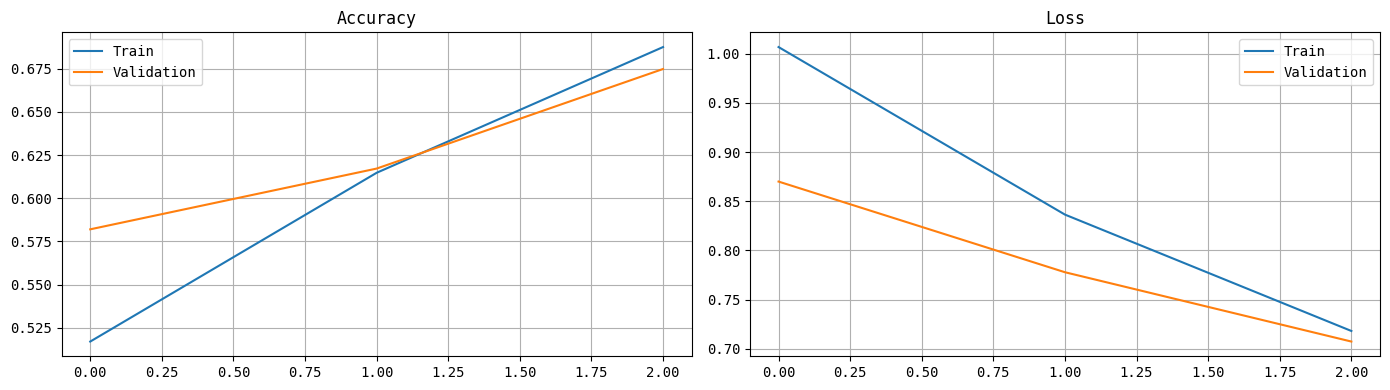

In [19]:
# Grafici loss e accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(True)
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.rcParams['font.family'] = 'monospace'
plt.show()

In [20]:
# epoca migliore (con loss minima)
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])
best_val_acc  = history.history['val_accuracy'][best_epoch - 1]

print(f"Epoca migliore:        {best_epoch}")
print(f"Val loss migliore:     {best_val_loss:.4f}")
print(f"Val accuracy migliore: {best_val_acc:.4f}")

Epoca migliore:        3
Val loss migliore:     0.7073
Val accuracy migliore: 0.6748


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step


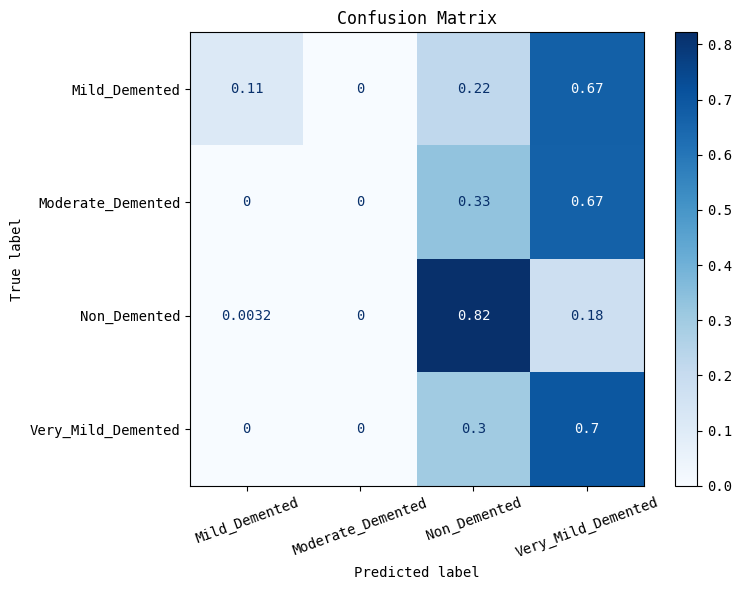

                    precision    recall  f1-score   support

     Mild_Demented       0.90      0.11      0.20       172
 Moderate_Demented       0.00      0.00      0.00        15
      Non_Demented       0.74      0.82      0.78       634
Very_Mild_Demented       0.58      0.70      0.63       459

          accuracy                           0.67      1280
         macro avg       0.56      0.41      0.40      1280
      weighted avg       0.70      0.67      0.64      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# predizioni sul test set — argmax converte da one-hot al numero della classe
test_pred = np.argmax(model.predict(test_images), axis=1)

# confusion matrix
cm = confusion_matrix(test_labels, test_pred,normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.xticks(rotation=20)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.rcParams['font.family'] = 'monospace'
plt.show()

# classification report — stampa precision, recall, f1 per ogni classe
# precision: quante predizioni positive erano davvero positive
# recall:    quante positive reali ha trovato il modello
# f1:        media armonica tra precision e recall — bilancia i due
print(classification_report(test_labels, test_pred, target_names=label_names))

Salvataggio di un file json con i risultati ottenuti con questo modello

In [1]:
import json
from datetime import datetime
test_loss, test_acc = model.evaluate(test_images, test_labels_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

risultati = {
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M"),
    'modello': 'VGG16_NoWeightsOnClass',
    'epoche_eseguite': len(history.history['loss']),
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'train_accuracy_finale': float(history.history['accuracy'][-1]),
    'val_accuracy_finale': float(history.history['val_accuracy'][-1]),
    'class_weights_usati': False,
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report(
        test_labels, test_pred,
        target_names=label_names,
        output_dict=True
    )
}

path = f'/content/drive/MyDrive/Project_For_ABIAML/risultati_CNN_scratch_seed{seed}.json'
with open(path, 'w') as f:
    json.dump(risultati, f, indent=2)

print(f"Salvato in: {path}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Macro F1: {risultati['classification_report']['macro avg']['f1-score']:.4f}")

NameError: name 'model' is not defined

Salvataggio del modello

In [ ]:
model.save('/content/drive/MyDrive/Project_For_ABIAML/vgg16_checkpoint.keras')
print("Modello salvato su Drive.")

Modello salvato su Drive.


volendo si può usare il modello salvato per continuare l'addestramento senza perdere il lavoro fatto

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step


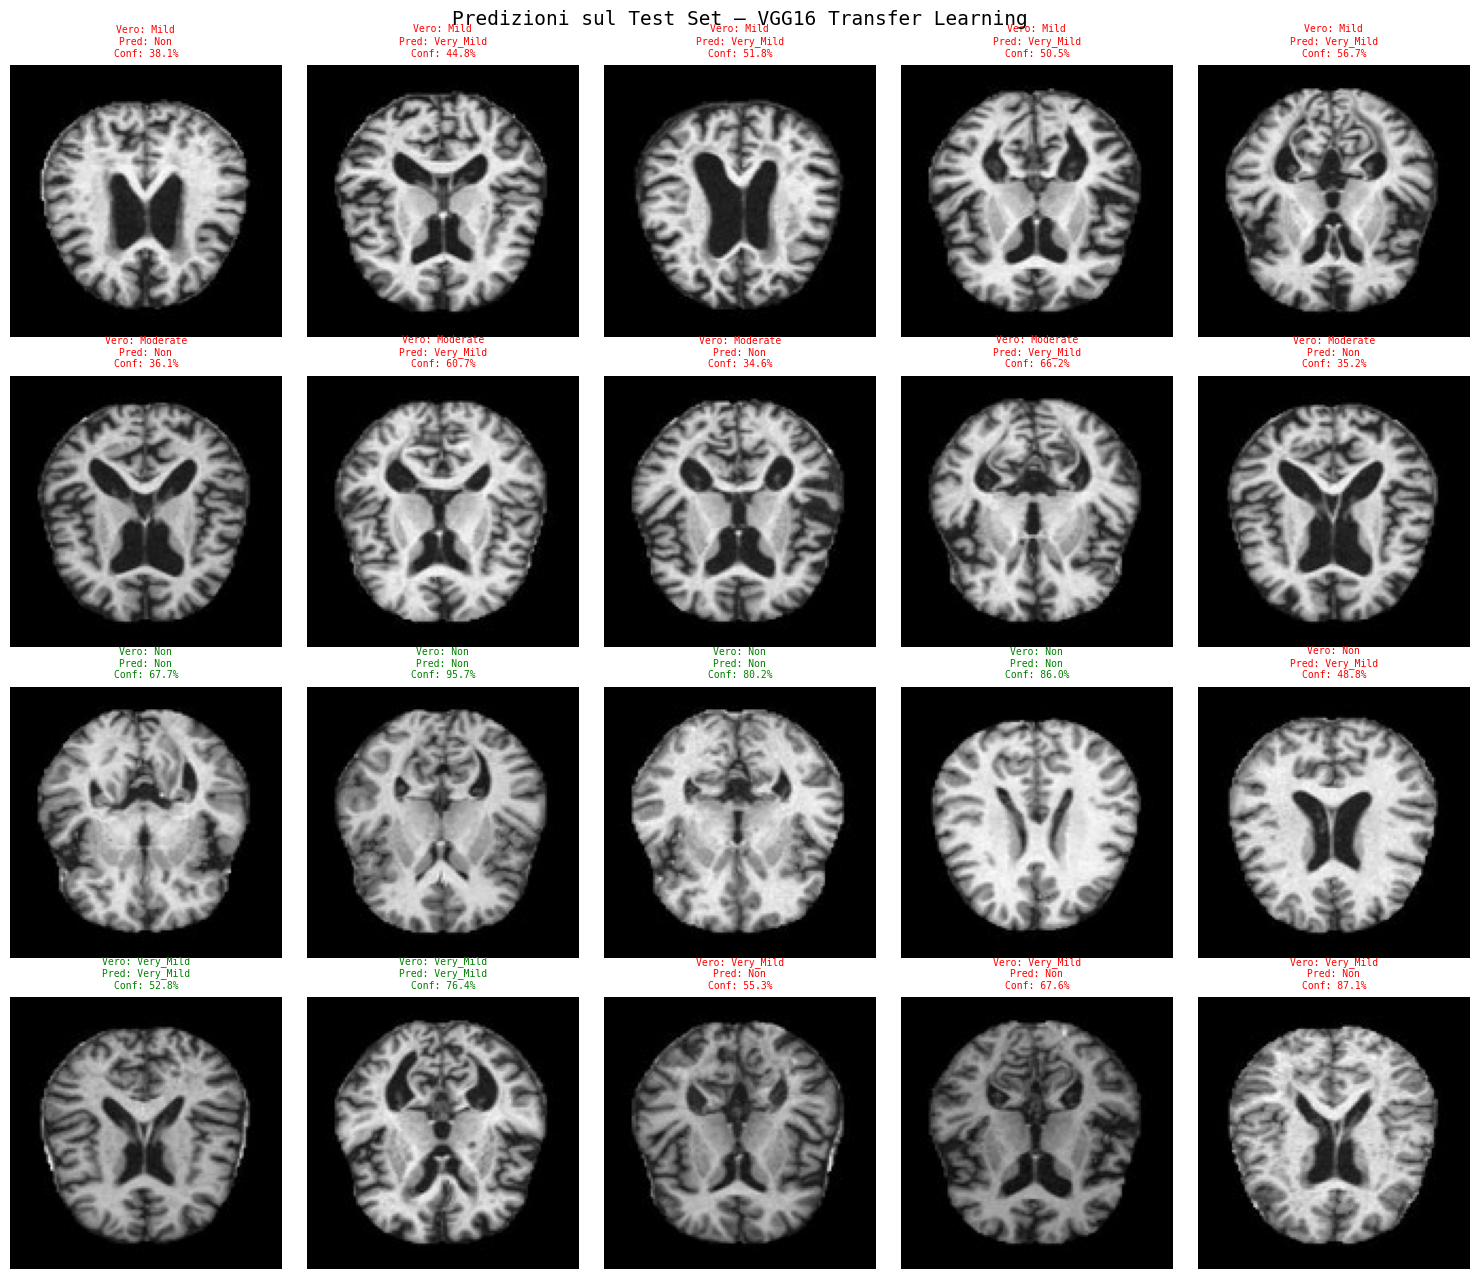

In [22]:
# ── BLOCCO VISUALIZZAZIONE PREDIZIONI ─────────────────────────────────────────
# Mostriamo alcune immagini del test set con la predizione del modello.
# Verde = predizione corretta, Rosso = predizione sbagliata.
# Mostriamo 5 esempi per classe per avere un quadro bilanciato (4 classi × 5 = 20 immagini).

import random
import numpy as np
import matplotlib.pyplot as plt

# Ricaviamo le classi vere e predette
true_classes = test_labels                            # array int shape (1280,)
pred_classes = np.argmax(model.predict(test_images), axis=1)  # già calcolato sopra come test_pred, puoi riusarlo

fig, axes = plt.subplots(4, 5, figsize=(15, 13))
fig.suptitle('Predizioni sul Test Set — VGG16 Transfer Learning', fontsize=14)

for class_idx, class_name in enumerate(label_names):

    # Trova gli indici delle immagini di questa classe nel test set
    class_indices = np.where(true_classes == class_idx)[0]

    # Seleziona 5 casuali (o meno se la classe ha pochi campioni — es. Moderate_Demented ha solo 15)
    selected = random.sample(list(class_indices), min(5, len(class_indices)))

    for col, idx in enumerate(selected):
        ax = axes[class_idx, col]

        # Mostra immagine — le nostre sono già (128,128,3), plt.imshow le gestisce direttamente
        ax.imshow(test_images[idx])

        true_label = label_names[true_classes[idx]]
        pred_label = label_names[pred_classes[idx]]

        # predictions è la matrice softmax — prendiamo la confidenza della classe predetta
        confidence = model.predict(test_images[idx:idx+1], verbose=0)[0].max() * 100

        # Titolo verde se corretto, rosso se sbagliato
        correct = true_classes[idx] == pred_classes[idx]
        color   = 'green' if correct else 'red'

        # Nomi abbreviati per leggibilità nel titolo
        true_short = true_label.replace('_Demented', '')
        pred_short = pred_label.replace('_Demented', '')

        ax.set_title(f"Vero: {true_short}\n"
                     f"Pred: {pred_short}\n"
                     f"Conf: {confidence:.1f}%",
                     color=color, fontsize=7)
        ax.axis('off')

    # Etichetta di riga con il nome della classe
    axes[class_idx, 0].set_ylabel(class_name.replace('_', '\n'),
                                   fontsize=8, rotation=0,
                                   labelpad=60, va='center')

plt.tight_layout()
plt.show()

VISUALIZZAZIONE GRAFICA DI UN SAMPLE PREDITTIVO